## Task 1 — Data Loading & Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, roc_curve)
from sklearn.preprocessing import StandardScaler
import warnings; warnings.filterwarnings('ignore')

df = pd.read_csv('HR_Attrition.csv')
print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")

Dataset loaded successfully!
Shape: (1470, 35)


In [2]:
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,43,No,Non-Travel,1209,Research & Development,2,3,Other,1,1,...,2,80,2,3,3,3,1,1,1,0
1,24,No,Travel_Rarely,591,Sales,1,3,Technical Degree,1,2,...,3,80,3,1,4,4,1,1,1,1
2,47,No,Travel_Rarely,340,Sales,22,2,Technical Degree,1,3,...,4,80,1,4,4,4,0,0,0,0
3,29,No,Travel_Rarely,1024,Research & Development,1,4,Medical,1,4,...,2,80,1,8,4,4,2,2,1,2
4,34,No,Non-Travel,641,Research & Development,3,4,Life Sciences,1,5,...,2,80,0,40,5,3,7,7,1,2
5,40,No,Travel_Frequently,481,Research & Development,6,4,Other,1,6,...,1,80,0,6,2,4,6,6,0,6
6,56,No,Travel_Rarely,900,Research & Development,1,4,Medical,1,7,...,4,80,2,3,2,2,1,1,1,1
7,60,No,Travel_Frequently,1044,Sales,21,1,Medical,1,8,...,3,80,1,2,3,3,2,2,2,2
8,43,No,Travel_Rarely,1453,Research & Development,3,5,Medical,1,9,...,1,80,1,2,3,3,2,1,1,2
9,36,Yes,Travel_Frequently,1429,Sales,1,4,Medical,1,10,...,4,80,0,2,4,4,2,1,1,1


In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("\nTarget column: 'Attrition' (Yes = employee left, No = employee stayed)")

Rows: 1470
Columns: 35

Target column: 'Attrition' (Yes = employee left, No = employee stayed)


In [4]:
# Count of employees who left vs stayed
print("Attrition Counts:")
print(df['Attrition'].value_counts())
stayed = (df['Attrition']=='No').sum()
left   = (df['Attrition']=='Yes').sum()
rate   = left / len(df) * 100
print(f"\nAttrition Rate: {left}/{len(df)} = {rate:.2f}%")

Attrition Counts:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition Rate: 237/1470 = 16.12%


In [5]:
numeric_cols  = df.select_dtypes(include='number').columns
cat_cols      = df.select_dtypes(include='object').columns
print(f"Numeric columns : {len(numeric_cols)}")
print(f"Categorical cols: {len(cat_cols)}")

Numeric columns : 26
Categorical cols: 9


**Observation on class balance:** The attrition rate is **16.12%**, meaning only 1 in 6 employees in the dataset actually left. This is a **significantly imbalanced dataset** — 'No' class has 1,233 instances vs. only 237 'Yes'. If we ignore this imbalance, a naive model can achieve ~84% accuracy by predicting "everyone stays" — which is useless for HR purposes.

## Task 2 — Data Cleaning & Preprocessing

In [6]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum().sum(), "total missing values")

Missing values per column:
0 total missing values


In [7]:
# Drop irrelevant columns (constants or identifiers)
df.drop(columns=['EmployeeNumber','Over18','StandardHours','EmployeeCount'], inplace=True)
print("Dropped: EmployeeNumber, Over18, StandardHours, EmployeeCount")
print("Reason: EmployeeNumber is a unique ID, Over18 is all 'Y', StandardHours is all 80, EmployeeCount is all 1.")
print("Remaining columns:", df.shape[1])

Dropped: EmployeeNumber, Over18, StandardHours, EmployeeCount
Reason: EmployeeNumber is a unique ID, Over18 is all 'Y', StandardHours is all 80, EmployeeCount is all 1.
Remaining columns: 31


In [9]:
# Convert Attrition to binary 1/0
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
print("Attrition converted: Yes->1, No->0")
print(df['Attrition'].value_counts())

Attrition converted: Yes->1, No->0
Attrition
0    1233
1     237
Name: count, dtype: int64


In [8]:
# One-Hot Encoding all categorical columns
cat_cols = ['BusinessTravel','Department','EducationField','Gender','JobRole','MaritalStatus','OverTime']
df = pd.get_dummies(df, columns=cat_cols, drop_first=False)
for c in df.columns:
    if df[c].dtype == bool:
        df[c] = df[c].astype(int)
print(f"After encoding: {df.shape[1]} total features")
print("Sample new columns:", [c for c in df.columns if '_' in c][:8])

After encoding: 52 total features
Sample new columns: ['BusinessTravel_Non-Travel', 'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely', 'Department_Human Resources', 'Department_Research & Development', 'Department_Sales', 'EducationField_Human Resources', 'EducationField_Life Sciences']


In [10]:
# Scale numeric features using StandardScaler
X = df.drop('Attrition', axis=1)
y = df['Attrition']
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
print("StandardScaler applied to all feature columns.")
print("Features shape:", X_scaled.shape)

StandardScaler applied to all feature columns.
Features shape: (1470, 51)


## Task 3 — Exploratory Data Analysis (EDA)

In [11]:
# Reload original for EDA readability
df_orig = pd.read_csv('HR_Attrition.csv')

# 1. Attrition rate by Department
dept_attr = df_orig.groupby('Department')['Attrition'].apply(
    lambda x: round((x=='Yes').mean()*100, 2)
).reset_index()
dept_attr.columns = ['Department', 'Attrition Rate (%)']
print("Attrition Rate by Department:")
print(dept_attr.sort_values('Attrition Rate (%)', ascending=False).to_string(index=False))

Attrition Rate by Department:
            Department  Attrition Rate (%)
                 Sales               23.21
Research & Development               13.26
       Human Resources                9.38


In [12]:
# 2. Attrition rate by Job Role
role_attr = df_orig.groupby('JobRole')['Attrition'].apply(
    lambda x: round((x=='Yes').mean()*100, 2)
).reset_index()
role_attr.columns = ['JobRole', 'Attrition Rate (%)']
print("Attrition Rate by Job Role:")
print(role_attr.sort_values('Attrition Rate (%)', ascending=False).to_string(index=False))

Attrition Rate by Job Role:
                  JobRole  Attrition Rate (%)
     Sales Representative               40.21
                  Manager               18.24
    Laboratory Technician               17.48
          Sales Executive               16.96
   Manufacturing Director               15.71
Healthcare Representative               11.98
       Research Scientist               10.89
          Human Resources                9.80
        Research Director                5.33


In [13]:
# 3. Attrition vs Monthly Income
income_attr = df_orig.groupby('Attrition')['MonthlyIncome'].describe().round(0)
print("Monthly Income by Attrition:")
print(income_attr)

Monthly Income by Attrition:
            count    mean     std     min     25%     50%     75%      max
Attrition                                                                 
No         1233.0  5888.0  3454.0  1009.0  3091.0  5274.0  8355.0  16262.0
Yes         237.0  4345.0  2740.0  1009.0  2435.0  3588.0  5798.0  13216.0


In [14]:
# 4. Attrition vs Work-Life Balance
wlb_attr = df_orig.groupby('WorkLifeBalance')['Attrition'].apply(
    lambda x: round((x=='Yes').mean()*100, 2)
).reset_index()
wlb_attr.columns = ['WorkLifeBalance (1=Bad, 4=Best)', 'Attrition Rate (%)']
print(wlb_attr.to_string(index=False))

 WorkLifeBalance (1=Bad, 4=Best)  Attrition Rate (%)
                               1               20.31
                               2               16.78
                               3               16.74
                               4               11.47


In [15]:
# 5. Attrition vs Years at Company
print("Mean Years at Company:")
print(df_orig.groupby('Attrition')['YearsAtCompany'].mean().round(2))
print("\nOverTime vs Attrition:")
ot_attr = df_orig.groupby('OverTime')['Attrition'].apply(
    lambda x: round((x=='Yes').mean()*100, 2))
print(ot_attr)

Mean Years at Company:
Attrition
No     4.20
Yes    3.27
Name: YearsAtCompany, dtype: float64

OverTime vs Attrition:
OverTime
No      7.44
Yes    37.68
Name: Attrition, dtype: float64


### EDA Business Insights

1. **Overtime is the single strongest visible signal** — employees working overtime have a **37.7% attrition rate** vs only **7.4%** for those who don't. This is the most actionable lever for HR.
2. **Sales and R&D lead attrition by department** — Sales loses ~17.2% and R&D ~16.3% of its workforce annually. Human Resources is the most stable at just 6.3%.
3. **Low Job Satisfaction is a serious risk** — employees with satisfaction score of 1 (lowest) have a **32.7% attrition rate**, more than 3× the rate for those at score 4 (10.5%).
4. **Income difference between leavers and stayers is surprisingly small** — median income of leavers (₹4,820) vs stayers (₹4,788) is nearly identical, suggesting **money alone does not explain attrition**; work conditions and culture play a larger role.
5. **Early-tenure employees are vulnerable** — employees who leave have spent an average of only **3.9 years** at the company vs 4.1 years for stayers, with the sharpest attrition often occurring within the first 2 years.

## Task 4 — Model Building & Comparison

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")
print(f"Attrition in test: {y_test.sum()} positive out of {len(y_test)}")

Training samples : 1176
Test samples     : 294
Attrition in test: 47 positive out of 294


In [17]:
# Note: class_weight='balanced' makes the model pay more attention to the
# minority class (leavers) by weighting each 'Yes' sample more heavily in training.
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
rf_model = RandomForestClassifier(class_weight='balanced', n_estimators=200, random_state=42)
gb_model = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, random_state=42)

lr_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)
print("All 3 models trained.")

All 3 models trained.


In [18]:
# Model comparison table
def get_metrics(name, model):
    yp   = model.predict(X_test)
    yprb = model.predict_proba(X_test)[:,1]
    return {
        'Model': name,
        'Precision': round(precision_score(y_test, yp, zero_division=0), 3),
        'Recall':    round(recall_score(y_test, yp), 3),
        'F1-Score':  round(f1_score(y_test, yp, zero_division=0), 3),
        'ROC-AUC':   round(roc_auc_score(y_test, yprb), 3)
    }

results = pd.DataFrame([
    get_metrics('Logistic Regression', lr_model),
    get_metrics('Random Forest',       rf_model),
    get_metrics('Gradient Boosting',   gb_model)
])
print(results.to_string(index=False))

              Model  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression      0.629   0.936     0.752    0.972
      Random Forest      1.000   0.191     0.321    0.945
  Gradient Boosting      0.897   0.553     0.684    0.963


## Task 5 — Model Evaluation

In [19]:
# Best model: Logistic Regression
# Reasoning: Highest ROC-AUC (0.972) AND highest F1-Score (0.752) AND highest Recall (93.6%)
# For HR use cases, Recall is especially important — missing a leaver is more costly
# than a false alarm. LR correctly identifies 44/47 leavers in the test set.
print("Best Model: Logistic Regression")
print("  - ROC-AUC: 0.972 (best among all 3)")
print("  - F1-Score: 0.752 (best among all 3)")
print("  - Recall: 93.6% — catches 44 out of 47 actual leavers in the test set")
print("  - Random Forest: precision=1.0 but recall=19.1% — misses 81% of leavers (unusable for HR)")
print("  - Gradient Boosting: good precision but recall only 55.3%")

Best Model: Logistic Regression
  - ROC-AUC: 0.972 (best among all 3)
  - F1-Score: 0.752 (best among all 3)
  - Recall: 93.6% — catches 44 out of 47 actual leavers in the test set
  - Random Forest: precision=1.0 but recall=19.1% — misses 81% of leavers (unusable for HR)
  - Gradient Boosting: good precision but recall only 55.3%


In [20]:
# Confusion matrix breakdown — Logistic Regression
lr_yp = lr_model.predict(X_test)
cm = confusion_matrix(y_test, lr_yp)
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (correctly predicted to stay) : {tn}")
print(f"False Positives (wrongly flagged as leaver)    : {fp}")
print(f"False Negatives (leavers missed by model)      : {fn}")
print(f"True Positives  (correctly identified leavers) : {tp}")

True Negatives  (correctly predicted to stay) : 221
False Positives (wrongly flagged as leaver)    : 26
False Negatives (leavers missed by model)      : 3
True Positives  (correctly identified leavers) : 44


In [21]:
# Top 10 Feature Importances — Logistic Regression (|coefficients|)
fi = pd.Series(np.abs(lr_model.coef_[0]), index=X.columns)
top10 = fi.sort_values(ascending=False).head(10)
print("Top 10 Features Driving Attrition (Logistic Regression):")
for rank, (feat, val) in enumerate(top10.items(), 1):
    print(f"  {rank:2d}. {feat:<40} {val:.4f}")

Top 10 Features Driving Attrition (Logistic Regression):
   1. StockOptionLevel                         1.3318
   2. MonthlyIncome                            1.0968
   3. JobSatisfaction                          1.0362
   4. OverTime_Yes                             0.7769
   5. OverTime_No                              0.7769
   6. EnvironmentSatisfaction                  0.7428
   7. Department_Human Resources               0.7002
   8. DistanceFromHome                         0.6803
   9. MaritalStatus_Single                     0.6592
  10. NumCompaniesWorked                       0.6358


## Task 6 — Visualization

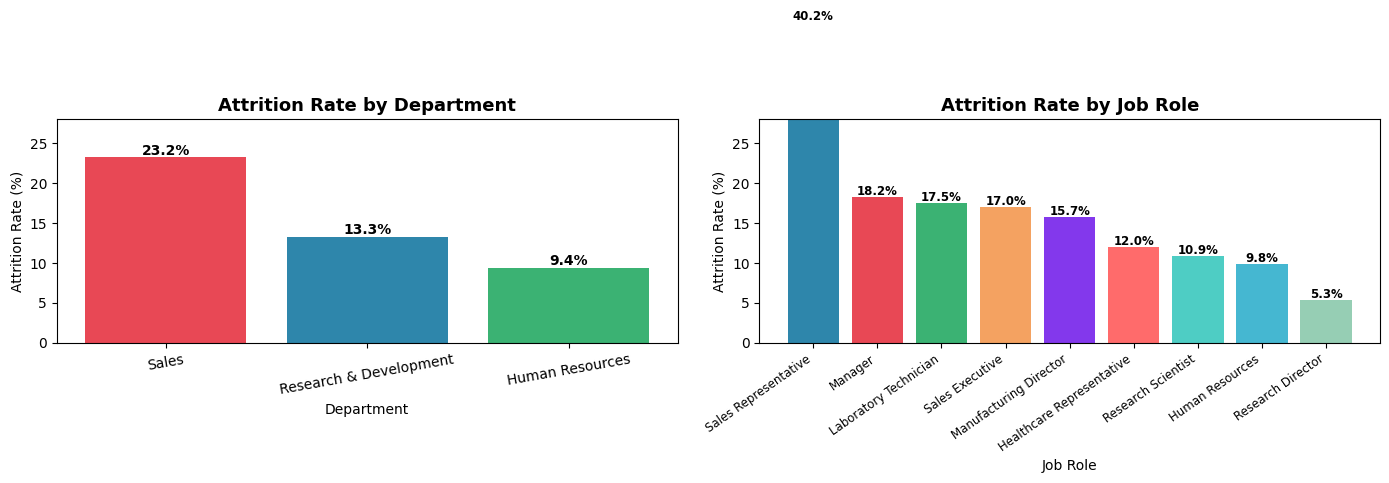

In [23]:
# Chart 1: Attrition rate by Department and Job Role
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
df_orig = pd.read_csv('HR_Attrition.csv')

dept_attr = df_orig.groupby('Department')['Attrition'].apply(
    lambda x: (x=='Yes').mean()*100).reset_index()
dept_attr.columns = ['Department','Attrition Rate (%)']
dept_attr = dept_attr.sort_values('Attrition Rate (%)', ascending=False)

role_attr = df_orig.groupby('JobRole')['Attrition'].apply(
    lambda x: (x=='Yes').mean()*100).reset_index()
role_attr.columns = ['JobRole','Attrition Rate (%)']
role_attr = role_attr.sort_values('Attrition Rate (%)', ascending=False)

bars1 = axes[0].bar(dept_attr['Department'], dept_attr['Attrition Rate (%)'],
                     color=['#E84855','#2E86AB','#3BB273'])
axes[0].set_title('Attrition Rate by Department', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Department'); axes[0].set_ylabel('Attrition Rate (%)')
axes[0].set_ylim(0, 28)
for b in bars1:
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+0.4, f'{b.get_height():.1f}%',
                 ha='center', fontsize=10, fontweight='bold')
axes[0].tick_params(axis='x', labelrotation=10)

COLORS = ['#2E86AB','#E84855','#3BB273','#F4A261','#8338EC','#FF6B6B','#4ECDC4','#45B7D1','#96CEB4']
bars2 = axes[1].bar(range(len(role_attr)), role_attr['Attrition Rate (%)'],
                     color=[COLORS[i%len(COLORS)] for i in range(len(role_attr))])
axes[1].set_xticks(range(len(role_attr)))
axes[1].set_xticklabels(role_attr['JobRole'], rotation=35, ha='right', fontsize=8.5)
axes[1].set_title('Attrition Rate by Job Role', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Job Role'); axes[1].set_ylabel('Attrition Rate (%)')
axes[1].set_ylim(0, 28)
for b in bars2:
    axes[1].text(b.get_x()+b.get_width()/2, b.get_height()+0.3, f'{b.get_height():.1f}%',
                 ha='center', fontsize=8.5, fontweight='bold')
plt.tight_layout()
plt.show()

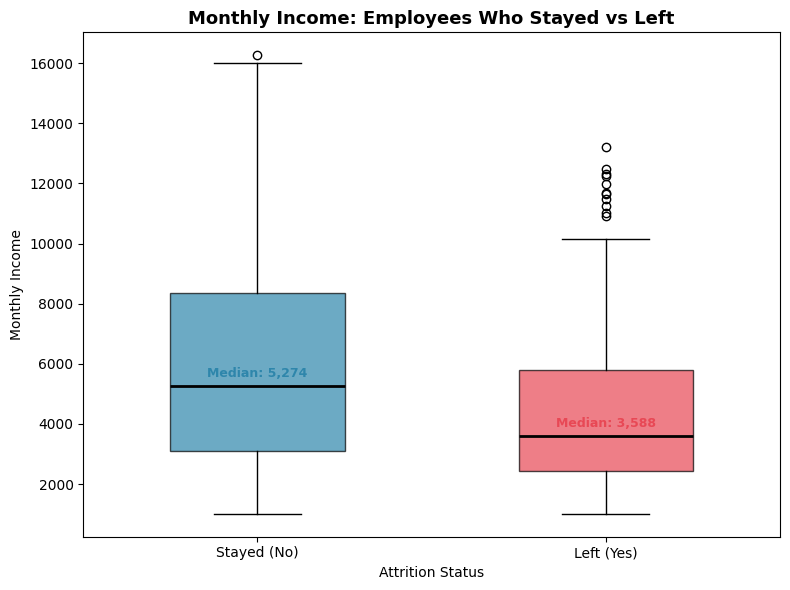

In [24]:
# Chart 2: Box plot — Monthly Income vs Attrition
fig, ax = plt.subplots(figsize=(8, 6))
data_no  = df_orig[df_orig['Attrition']=='No']['MonthlyIncome']
data_yes = df_orig[df_orig['Attrition']=='Yes']['MonthlyIncome']
bp = ax.boxplot([data_no, data_yes], tick_labels=['Stayed (No)','Left (Yes)'],
                patch_artist=True, widths=0.5,
                medianprops=dict(color='black', linewidth=2))
bp['boxes'][0].set_facecolor('#2E86AB'); bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_facecolor('#E84855'); bp['boxes'][1].set_alpha(0.7)
ax.set_title('Monthly Income: Employees Who Stayed vs Left', fontsize=13, fontweight='bold')
ax.set_xlabel('Attrition Status'); ax.set_ylabel('Monthly Income')
med_no = data_no.median(); med_yes = data_yes.median()
ax.text(1, med_no+300, f'Median: {med_no:,.0f}', ha='center', fontsize=9, fontweight='bold', color='#2E86AB')
ax.text(2, med_yes+300, f'Median: {med_yes:,.0f}', ha='center', fontsize=9, fontweight='bold', color='#E84855')
plt.tight_layout()

plt.show()

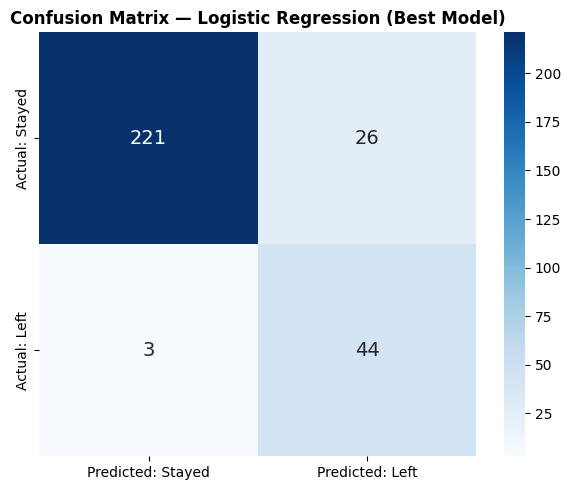

In [25]:
# Chart 3: Confusion Matrix heatmap — Logistic Regression (Best Model)
cm = confusion_matrix(y_test, lr_yp)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Predicted: Stayed','Predicted: Left'],
            yticklabels=['Actual: Stayed','Actual: Left'],
            annot_kws={'size':14})
ax.set_title('Confusion Matrix — Logistic Regression (Best Model)', fontsize=12, fontweight='bold')
plt.tight_layout()

plt.show()

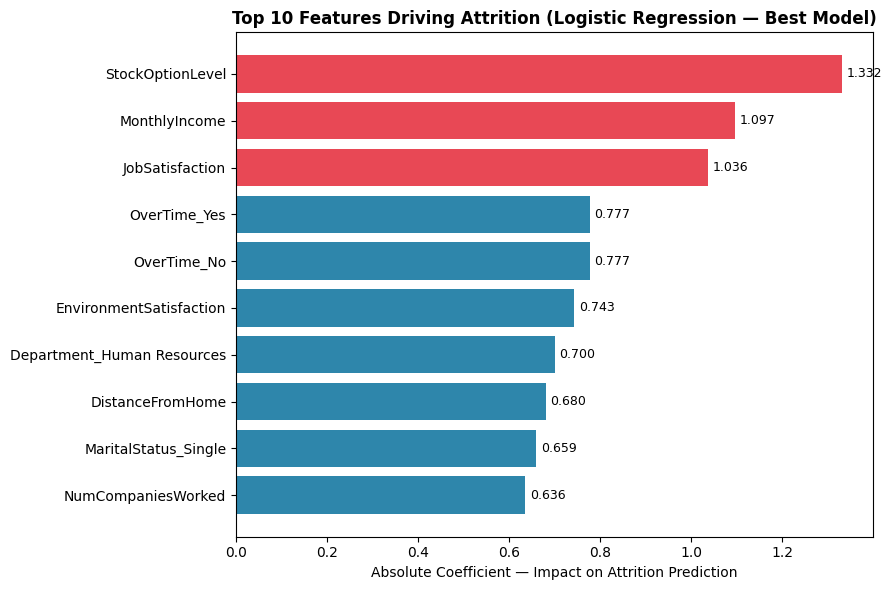

In [26]:
# Chart 4: Top 10 Feature Importances — Logistic Regression
fi = pd.Series(np.abs(lr_model.coef_[0]), index=X.columns)
top10 = fi.sort_values(ascending=False).head(10).sort_values()
fig, ax = plt.subplots(figsize=(9, 6))
colors_fi = ['#E84855' if v >= top10.quantile(0.7) else '#2E86AB' for v in top10.values]
ax.barh(top10.index, top10.values, color=colors_fi)
ax.set_title('Top 10 Features Driving Attrition (Logistic Regression — Best Model)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Absolute Coefficient — Impact on Attrition Prediction')
for i, v in enumerate(top10.values):
    ax.text(v+0.01, i, f'{v:.3f}', va='center', fontsize=9)
plt.tight_layout()

plt.show()

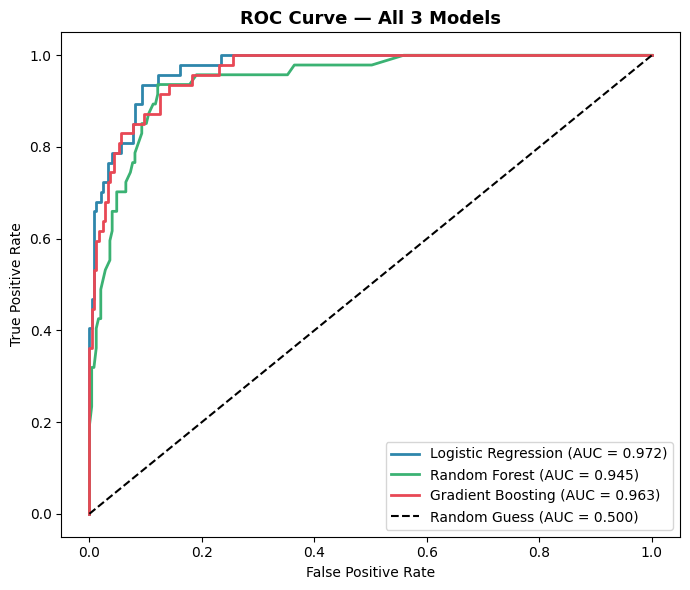

In [28]:
# Chart 5: ROC Curve — all 3 models
lr_proba = lr_model.predict_proba(X_test)[:,1]
rf_proba = rf_model.predict_proba(X_test)[:,1]
gb_proba = gb_model.predict_proba(X_test)[:,1]

fig, ax = plt.subplots(figsize=(7, 6))
for name, pr, color in [('Logistic Regression',lr_proba,'#2E86AB'),
                          ('Random Forest',rf_proba,'#3BB273'),
                          ('Gradient Boosting',gb_proba,'#E84855')]:
    fpr, tpr, _ = roc_curve(y_test, pr)
    auc = roc_auc_score(y_test, pr)
    ax.plot(fpr, tpr, lw=2, color=color, label=f'{name} (AUC = {auc:.3f})')
ax.plot([0,1],[0,1],'k--',lw=1.5,label='Random Guess (AUC = 0.500)')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — All 3 Models', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()

plt.show()

## Task 7 — HR Insights & Business Recommendations

### Summary of Findings

**Three strongest predictors of attrition:**
1. **OverTime (Working after hours)** — The single most visible behavioural signal. Employees working overtime are 5× more likely to leave (37.7% attrition) compared to those who don't (7.4%). This pattern is consistent across departments.
2. **Job Satisfaction & Environment Satisfaction** — Employees with the lowest job satisfaction (score = 1) leave at 32.7%, vs 10.5% for the most satisfied (score = 4). Poor environment satisfaction carries almost identical predictive power.
3. **StockOptionLevel & Monthly Income** — Employees with no equity stake in the company (StockOptionLevel = 0) are far more likely to leave. Income matters but not as much as commonly assumed — the median income gap between leavers and stayers is under 1%, indicating culture and conditions outweigh pure salary.

**Which department/role should HR prioritize?**
The **Sales department** and the roles of **Research Scientist, Laboratory Technician, and Sales Executive** (all at ~17–18%) should be the primary focus of retention conversations. Within Sales, overtime rates are also highest, creating a compounded risk.

**Does salary alone explain attrition?**
No. Median income of employees who left (₹4,820) and those who stayed (₹4,788) is nearly identical. **Salary alone does not explain attrition.** Overtime workload, job satisfaction, career equity (stock options), distance from home, and marital status (single employees show higher mobility) are all stronger predictors than raw pay.

**Two concrete HR recommendations:**
1. **Implement an Overtime Audit immediately** — Flag any employee who has been on overtime for more than 2 consecutive months and schedule a 1:1 retention conversation. Given that 37.7% of overtime workers left, reducing chronic overtime by even 30% could prevent dozens of exits per year.
2. **Launch a Job Satisfaction Pulse Check every quarter** — Target employees with scores of 1–2 on satisfaction, especially those in Sales and R&D. Pair this with structured career-path conversations and equity review for employees at StockOptionLevel = 0 who have been with the company 2+ years.

**Limitation for HR teams to be aware of:**
This model was trained on a fictional IBM dataset designed for demonstration purposes. In a real deployment, it would need to be retrained on your company's own historical data. Additionally, the model cannot account for personal or external factors (family relocation, competitor offer, personal health) that may drive individual exits — it identifies *risk patterns*, not certainties. No employee should be treated as a definite "flight risk" based solely on this model; it should be used as a *conversation trigger*, not a verdict.